In [1]:
import pandas as pd
sch_df = pd.read_csv("../data/raw/07_scheme_performance.csv")
sch_df.head()

,amfi_code,scheme_name,fund_house,category,plan,return_1yr_pct,return_3yr_pct,return_5yr_pct,benchmark_3yr_pct,alpha,beta,sharpe_ratio,sortino_ratio,std_dev_ann_pct,max_drawdown_pct,aum_crore,expense_ratio_pct,morningstar_rating,risk_grade
0,119551,SBI Bluechip Fund - Regular Plan - Growth,SBI Mutual Fund,Large Cap,Regular,12.42,12.36,14.45,11.49,0.87,0.89,0.88,1.29,14.0,-21.70,14288,1.54,4,Moderate
1,119552,SBI Bluechip Fund - Direct Plan - Growth,SBI Mutual Fund,Large Cap,Direct,15.25,11.30,14.23,9.52,1.78,0.87,0.81,1.29,14.0,-24.43,1231,0.66,3,Moderate
2,119598,SBI Small Cap Fund - Regular Plan - Growth,SBI Mutual Fund,Small Cap,Regular,24.56,23.39,20.67,22.16,1.23,0.89,0.94,1.35,25.0,-13.35,19259,1.43,5,Very High
3,119599,SBI Small Cap Fund - Direct Plan - Growth,SBI Mutual Fund,Small Cap,Direct,20.59,23.14,21.82,22.01,1.13,1.04,0.93,1.67,25.0,-24.78,36061,0.72,4,Very High
4,119120,SBI Magnum Gilt Fund - Regular Plan - Growth,SBI Mutual Fund,Gilt,Regular,5.34,6.07,5.43,4.47,1.60,0.22,1.52,2.11,4.0,-2.30,24101,0.77,5,Low


In [2]:
sch_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40 entries, 0 to 39
Data columns (total 19 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   amfi_code           40 non-null     int64  
 1   scheme_name         40 non-null     object 
 2   fund_house          40 non-null     object 
 3   category            40 non-null     object 
 4   plan                40 non-null     object 
 5   return_1yr_pct      40 non-null     float64
 6   return_3yr_pct      40 non-null     float64
 7   return_5yr_pct      40 non-null     float64
 8   benchmark_3yr_pct   40 non-null     float64
 9   alpha               40 non-null     float64
 10  beta                40 non-null     float64
 11  sharpe_ratio        40 non-null     float64
 12  sortino_ratio       40 non-null     float64
 13  std_dev_ann_pct     40 non-null     float64
 14  max_drawdown_pct    40 non-null     float64
 15  aum_crore           40 non-null     int64  
 16  expense_ra

In [3]:
sch_df.isnull().sum()

amfi_code             0
scheme_name           0
fund_house            0
category              0
plan                  0
return_1yr_pct        0
return_3yr_pct        0
return_5yr_pct        0
benchmark_3yr_pct     0
alpha                 0
beta                  0
sharpe_ratio          0
sortino_ratio         0
std_dev_ann_pct       0
max_drawdown_pct      0
aum_crore             0
expense_ratio_pct     0
morningstar_rating    0
risk_grade            0
dtype: int64

In [4]:
sch_df.duplicated().sum()

np.int64(0)

In [5]:
sch_df.columns

Index(['amfi_code', 'scheme_name', 'fund_house', 'category', 'plan',
       'return_1yr_pct', 'return_3yr_pct', 'return_5yr_pct',
       'benchmark_3yr_pct', 'alpha', 'beta', 'sharpe_ratio', 'sortino_ratio',
       'std_dev_ann_pct', 'max_drawdown_pct', 'aum_crore', 'expense_ratio_pct',
       'morningstar_rating', 'risk_grade'],
      dtype='object')

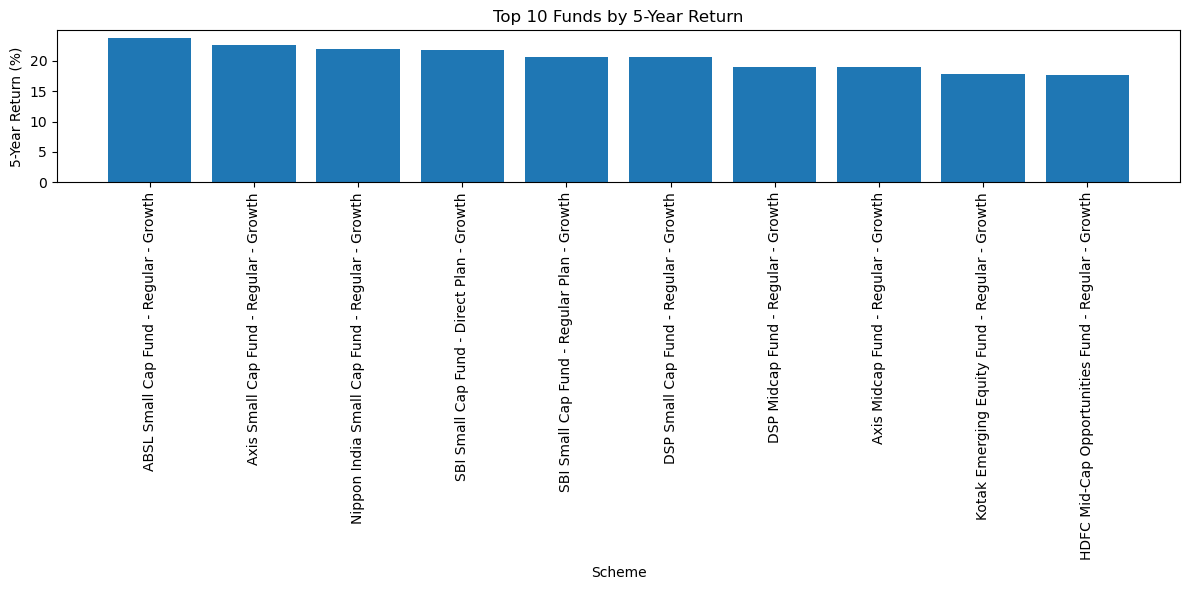

In [6]:
import matplotlib.pyplot as plt

top10 = sch_df.sort_values('return_5yr_pct', ascending=False).head(10)

plt.figure(figsize=(12,6))
plt.bar(top10['scheme_name'], top10['return_5yr_pct'])
plt.xticks(rotation=90)
plt.title("Top 10 Funds by 5-Year Return")
plt.xlabel("Scheme")
plt.ylabel("5-Year Return (%)")
plt.tight_layout()
plt.show()

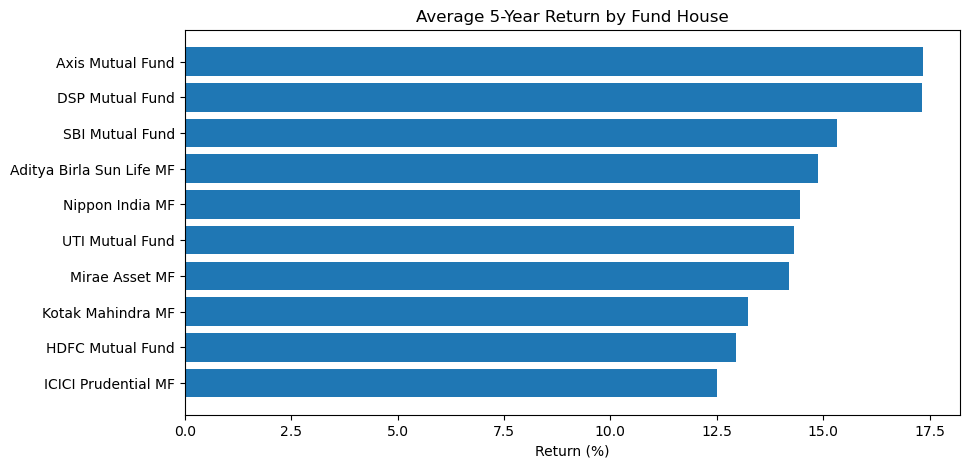

In [7]:
avg_return = sch_df.groupby('fund_house')['return_5yr_pct'].mean().sort_values()

plt.figure(figsize=(10,5))
plt.barh(avg_return.index, avg_return.values)
plt.title("Average 5-Year Return by Fund House")
plt.xlabel("Return (%)")
plt.show()

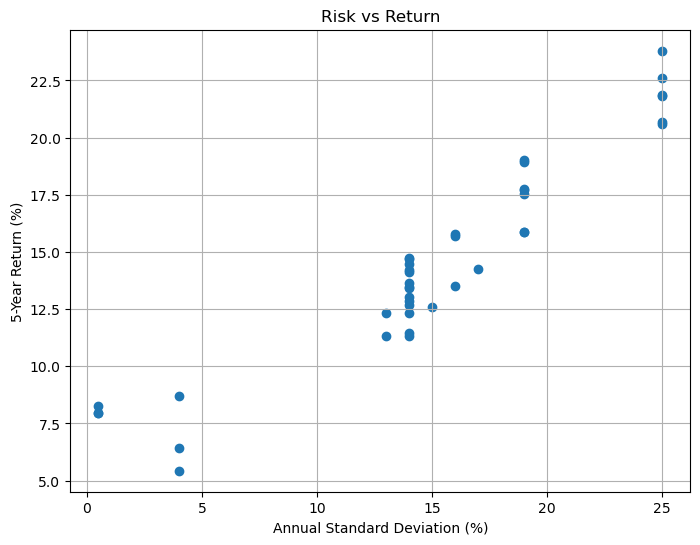

In [8]:
plt.figure(figsize=(8,6))

plt.scatter(
    sch_df['std_dev_ann_pct'],
    sch_df['return_5yr_pct']
)

plt.xlabel("Annual Standard Deviation (%)")
plt.ylabel("5-Year Return (%)")
plt.title("Risk vs Return")
plt.grid(True)

plt.show()

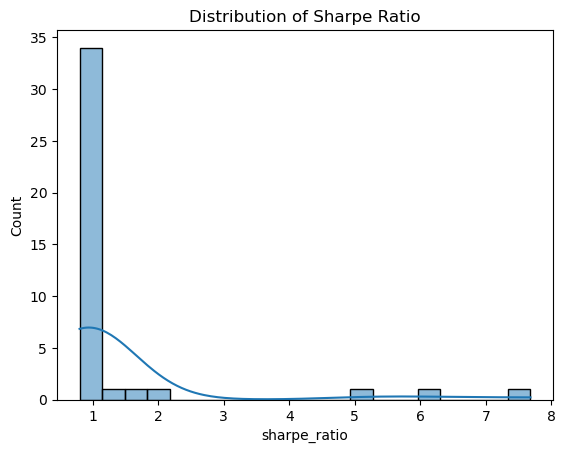

In [9]:
import seaborn as sns

sns.histplot(sch_df['sharpe_ratio'], bins=20, kde=True)

plt.title("Distribution of Sharpe Ratio")
plt.show()

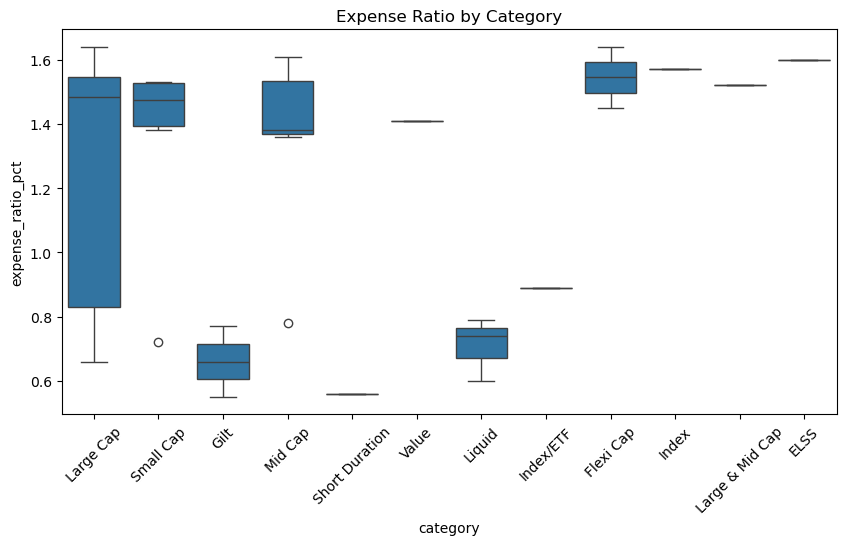

In [10]:
plt.figure(figsize=(10,5))

sns.boxplot(
    x='category',
    y='expense_ratio_pct',
    data=sch_df
)

plt.xticks(rotation=45)
plt.title("Expense Ratio by Category")
plt.show()

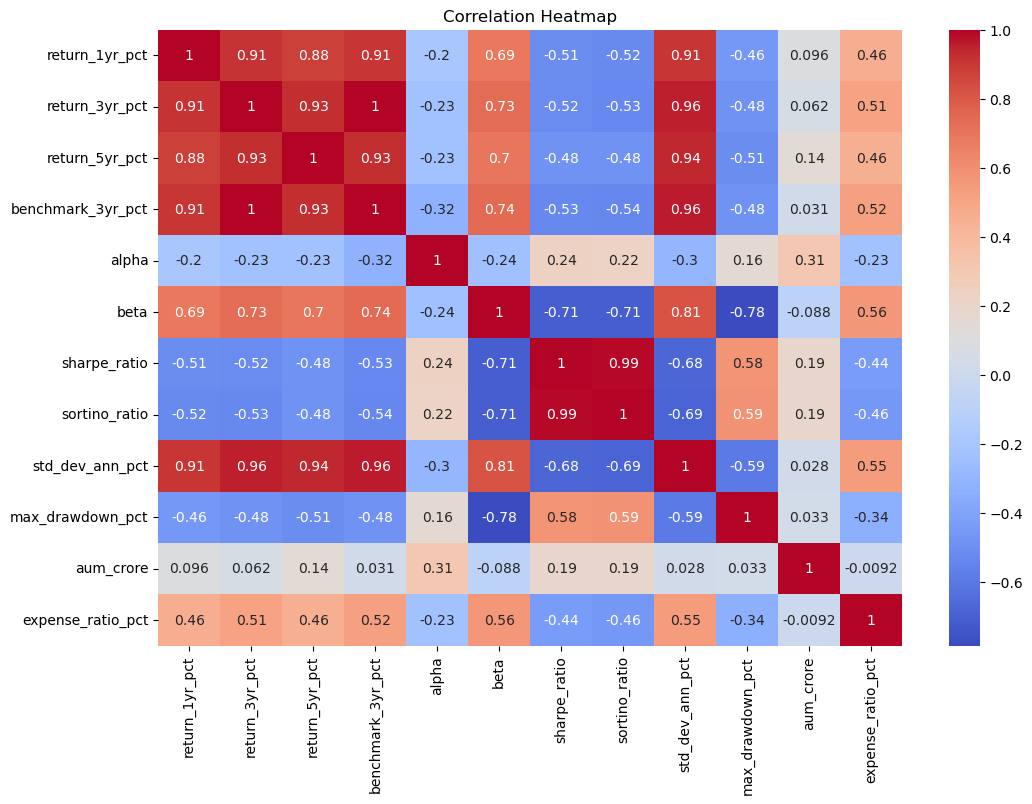

In [11]:
numeric = [
    'return_1yr_pct',
    'return_3yr_pct',
    'return_5yr_pct',
    'benchmark_3yr_pct',
    'alpha',
    'beta',
    'sharpe_ratio',
    'sortino_ratio',
    'std_dev_ann_pct',
    'max_drawdown_pct',
    'aum_crore',
    'expense_ratio_pct'
]

plt.figure(figsize=(12,8))

sns.heatmap(
    sch_df[numeric].corr(),
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation Heatmap")
plt.show()

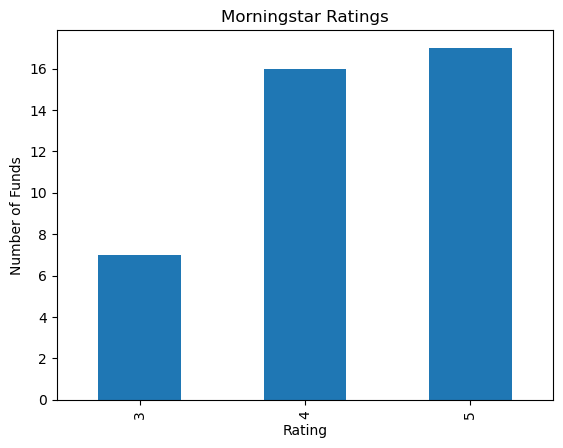

In [12]:
sch_df['morningstar_rating'].value_counts().sort_index().plot(
    kind='bar'
)

plt.title("Morningstar Ratings")
plt.xlabel("Rating")
plt.ylabel("Number of Funds")

plt.show()

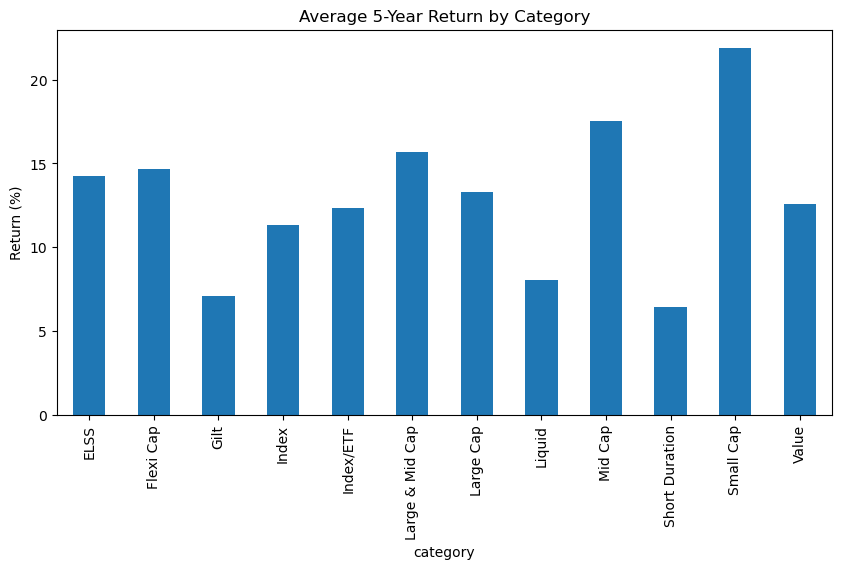

In [13]:
category_return = sch_df.groupby('category')['return_5yr_pct'].mean()

category_return.plot(
    kind='bar',
    figsize=(10,5)
)

plt.title("Average 5-Year Return by Category")
plt.ylabel("Return (%)")

plt.show()

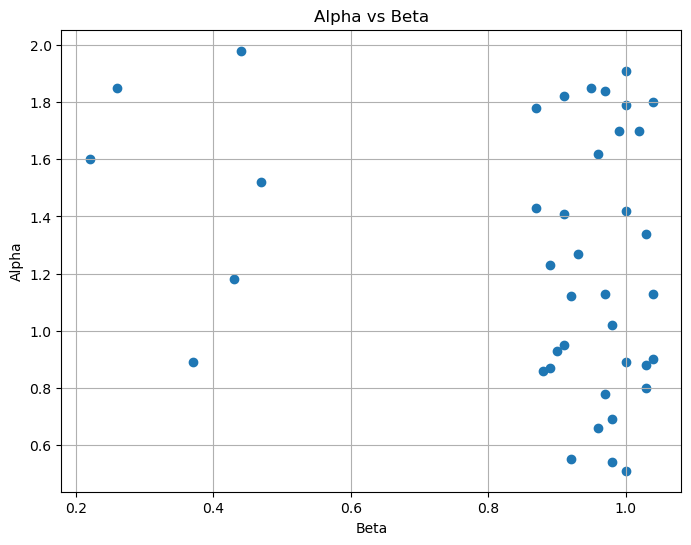

In [14]:
plt.figure(figsize=(8,6))

plt.scatter(
    sch_df['beta'],
    sch_df['alpha']
)

plt.xlabel("Beta")
plt.ylabel("Alpha")
plt.title("Alpha vs Beta")

plt.grid(True)

plt.show()

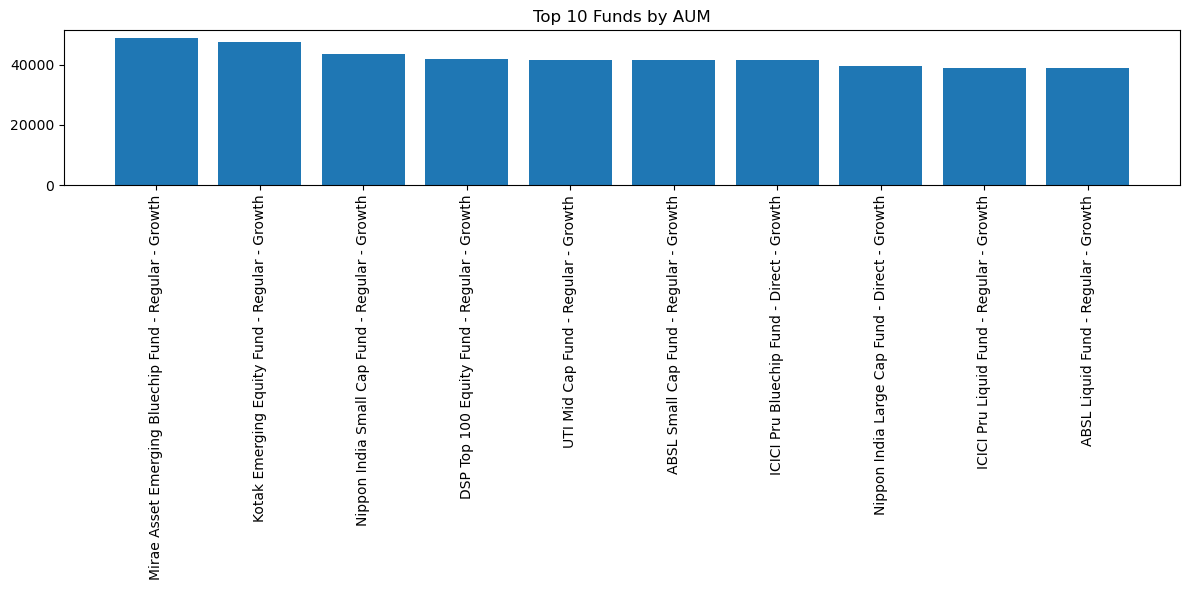

In [15]:
top = sch_df.sort_values(
    'aum_crore',
    ascending=False
).head(10)

plt.figure(figsize=(12,6))

plt.bar(top['scheme_name'], top['aum_crore'])

plt.xticks(rotation=90)

plt.title("Top 10 Funds by AUM")

plt.tight_layout()

plt.show()